# Notebook 03: Improved Denial-Risk Model Comparison

This notebook improves the less-leaky denial-risk model by testing multiple machine learning algorithms.

The goal is to compare models using the same processed CMS modeling dataset and select the best production candidate for the DenialOps AI dashboard.

The target variable is `denial_risk_proxy`, which was created in Notebook 01 using reimbursement-friction signals. Since this is a proxy label and not a true hospital denial outcome, the model should be interpreted as a reimbursement-risk scoring system, not a final denial decision engine.

## 1. Imports

This section imports the libraries needed for data loading, preprocessing, model training, evaluation, threshold tuning, visualization, and model saving.

In [1]:
# Import libraries for data loading, preprocessing, modeling, evaluation, visualization, and model saving

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Model comparison environment ready")

Model comparison environment ready


## 2. Load Modeling Dataset

This section loads the final 250,000-row modeling dataset created in Notebook 01.

The dataset already contains selected CMS provider-service fields, engineered reimbursement features, and the proxy denial-risk target.

In [2]:
# Load the final modeling dataset created in Notebook 01

path = "../data/processed/denial_risk_modeling_sample_250k.csv"

df = pd.read_csv(path)

print(df.shape)
df.head()

(250000, 24)


,provider_npi,provider_state,provider_type,medicare_participating,hcpcs_code,hcpcs_description,is_drug,place_of_service,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount,charge_to_allowed_ratio,payment_to_charge_ratio,payment_to_allowed_ratio,services_per_beneficiary,high_charge_allowed_ratio,low_payment_charge_ratio,high_service_intensity,risk_score,denial_risk_proxy
0,1003882531,UT,Family Practice,Y,77067,Screening mammography,N,O,11,11.0,11,325.660000,84.184545,84.184545,90.226364,3.868406,0.258504,1.000000,1.000000,0,0,0,0,0
1,1992254726,TX,Nurse Practitioner,Y,87804,Detection test by immunoassay with direct visu...,N,O,11,11.0,11,50.000000,16.220000,16.220000,16.220000,3.082614,0.324400,1.000000,1.000000,0,0,0,0,0
2,1750657938,PA,Emergency Medicine,Y,99285,Emergency department visit with high level of ...,N,F,51,51.0,51,1377.980392,172.981765,133.733333,130.515294,7.966044,0.097050,0.773107,1.000000,1,1,0,2,1
3,1205611712,FL,Nurse Practitioner,Y,99350,Residence visit for established patient with h...,N,O,56,75.0,75,180.900000,154.000000,122.700000,122.450000,1.174675,0.678275,0.796753,1.339286,0,0,0,0,0
4,1023763927,MD,Physical Therapist in Private Practice,Y,97110,Therapy procedure using exercise to develop st...,N,O,77,917.0,811,75.000000,28.049662,21.247874,19.097012,2.673829,0.283305,0.757509,11.909091,0,0,1,1,0


In [3]:
# Check the dataset columns and datatypes before modeling

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 24 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   provider_npi                      250000 non-null  int64  
 1   provider_state                    250000 non-null  object 
 2   provider_type                     250000 non-null  object 
 3   medicare_participating            250000 non-null  object 
 4   hcpcs_code                        250000 non-null  object 
 5   hcpcs_description                 250000 non-null  object 
 6   is_drug                           250000 non-null  object 
 7   place_of_service                  250000 non-null  object 
 8   total_beneficiaries               250000 non-null  int64  
 9   total_services                    250000 non-null  float64
 10  total_beneficiary_day_services    250000 non-null  int64  
 11  avg_submitted_charge              250000 non-null  f

In [4]:
# Check the target class balance for the proxy denial-risk label

df["denial_risk_proxy"].value_counts()

denial_risk_proxy
0    190698
1     59302
Name: count, dtype: int64

In [5]:
# Check the target class balance as percentages

df["denial_risk_proxy"].value_counts(normalize=True)

denial_risk_proxy
0    0.762792
1    0.237208
Name: proportion, dtype: float64

## 3. Safer Feature Engineering

This section creates safer features for the less-leaky model.

The direct proxy-label input features are not used:

- `charge_to_allowed_ratio`
- `payment_to_charge_ratio`
- `payment_to_allowed_ratio`
- `services_per_beneficiary`

Instead, this notebook uses provider, service, volume, and reimbursement amount fields. Log transformations are added to reduce skew in high-volume and high-dollar fields.

In [6]:
# Create log-transformed numeric features to reduce skew in high-volume and high-dollar columns

df["log_total_services"] = np.log1p(df["total_services"])
df["log_total_beneficiaries"] = np.log1p(df["total_beneficiaries"])
df["log_total_beneficiary_day_services"] = np.log1p(df["total_beneficiary_day_services"])

df["log_avg_submitted_charge"] = np.log1p(df["avg_submitted_charge"])
df["log_avg_medicare_allowed_amount"] = np.log1p(df["avg_medicare_allowed_amount"])
df["log_avg_medicare_payment_amount"] = np.log1p(df["avg_medicare_payment_amount"])
df["log_avg_medicare_standardized_amount"] = np.log1p(df["avg_medicare_standardized_amount"])

df.head()

,provider_npi,provider_state,provider_type,medicare_participating,hcpcs_code,hcpcs_description,is_drug,place_of_service,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount,charge_to_allowed_ratio,payment_to_charge_ratio,payment_to_allowed_ratio,services_per_beneficiary,high_charge_allowed_ratio,low_payment_charge_ratio,high_service_intensity,risk_score,denial_risk_proxy,log_total_services,log_total_beneficiaries,log_total_beneficiary_day_services,log_avg_submitted_charge,log_avg_medicare_allowed_amount,log_avg_medicare_payment_amount,log_avg_medicare_standardized_amount
0,1003882531,UT,Family Practice,Y,77067,Screening mammography,N,O,11,11.0,11,325.660000,84.184545,84.184545,90.226364,3.868406,0.258504,1.000000,1.000000,0,0,0,0,0,2.484907,2.484907,2.484907,5.788920,4.444820,4.444820,4.513344
1,1992254726,TX,Nurse Practitioner,Y,87804,Detection test by immunoassay with direct visu...,N,O,11,11.0,11,50.000000,16.220000,16.220000,16.220000,3.082614,0.324400,1.000000,1.000000,0,0,0,0,0,2.484907,2.484907,2.484907,3.931826,2.846071,2.846071,2.846071
2,1750657938,PA,Emergency Medicine,Y,99285,Emergency department visit with high level of ...,N,F,51,51.0,51,1377.980392,172.981765,133.733333,130.515294,7.966044,0.097050,0.773107,1.000000,1,1,0,2,1,3.951244,3.951244,3.951244,7.229100,5.158950,4.903298,4.879123
3,1205611712,FL,Nurse Practitioner,Y,99350,Residence visit for established patient with h...,N,O,56,75.0,75,180.900000,154.000000,122.700000,122.450000,1.174675,0.678275,0.796753,1.339286,0,0,0,0,0,4.330733,4.043051,4.330733,5.203457,5.043425,4.817859,4.815836
4,1023763927,MD,Physical Therapist in Private Practice,Y,97110,Therapy procedure using exercise to develop st...,N,O,77,917.0,811,75.000000,28.049662,21.247874,19.097012,2.673829,0.283305,0.757509,11.909091,0,0,1,1,0,6.822197,4.356709,6.699500,4.330733,3.369007,3.102246,3.000571


In [7]:
# Group rare HCPCS codes to reduce high-cardinality noise

top_hcpcs_codes = (
    df["hcpcs_code"]
    .value_counts()
    .head(500)
    .index
)

df["hcpcs_code_grouped"] = np.where(
    df["hcpcs_code"].isin(top_hcpcs_codes),
    df["hcpcs_code"],
    "OTHER"
)

df["hcpcs_code_grouped"].value_counts().head()

hcpcs_code_grouped
OTHER    30670
99214    13250
99213    11986
99204     6005
99232     4515
Name: count, dtype: int64

In [51]:
# Save the top HCPCS codes used for grouping so the Streamlit app can recreate the same feature logic

top_hcpcs_codes_path = "../models/top_hcpcs_codes.joblib"

joblib.dump(list(top_hcpcs_codes), top_hcpcs_codes_path)

print(f"Top HCPCS codes saved to {top_hcpcs_codes_path}")

Top HCPCS codes saved to ../models/top_hcpcs_codes.joblib


## 4. Define Features and Target

This section defines the model input features and the target variable.

The feature set excludes direct proxy-label input features to reduce leakage.

In [8]:
# Define the less-leaky feature set for model comparison

features = [
    "provider_state",
    "provider_type",
    "medicare_participating",
    "hcpcs_code_grouped",
    "is_drug",
    "place_of_service",
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount",
    "log_total_services",
    "log_total_beneficiaries",
    "log_total_beneficiary_day_services",
    "log_avg_submitted_charge",
    "log_avg_medicare_allowed_amount",
    "log_avg_medicare_payment_amount",
    "log_avg_medicare_standardized_amount"
]

target = "denial_risk_proxy"

features_df = df[features].copy()
target_series = df[target].copy()

print(features_df.shape)
print(target_series.shape)

(250000, 20)
(250000,)


In [9]:
# Separate categorical and numeric features for preprocessing

categorical_features = [
    "provider_state",
    "provider_type",
    "medicare_participating",
    "hcpcs_code_grouped",
    "is_drug",
    "place_of_service"
]

numeric_features = [
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount",
    "log_total_services",
    "log_total_beneficiaries",
    "log_total_beneficiary_day_services",
    "log_avg_submitted_charge",
    "log_avg_medicare_allowed_amount",
    "log_avg_medicare_payment_amount",
    "log_avg_medicare_standardized_amount"
]

print("Categorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))

Categorical features: 6
Numeric features: 14


## 5. Train/Test Split

This section splits the data into training and test sets.

Stratification is used so the target class distribution remains consistent between the training and test data.

In [10]:
# Split the dataset into training and test sets while preserving class balance

features_train, features_test, target_train, target_test = train_test_split(
    features_df,
    target_series,
    test_size=0.2,
    random_state=42,
    stratify=target_series
)

print(features_train.shape)
print(features_test.shape)
print(target_train.value_counts(normalize=True))
print(target_test.value_counts(normalize=True))

(200000, 20)
(50000, 20)
denial_risk_proxy
0    0.76279
1    0.23721
Name: proportion, dtype: float64
denial_risk_proxy
0    0.7628
1    0.2372
Name: proportion, dtype: float64


## 6. Preprocessing Pipelines

This section creates reusable preprocessing steps.

- Logistic Regression uses one-hot encoding and scaled numeric features.
- Random Forest, Extra Trees, and XGBoost use one-hot encoding and passthrough numeric features.
- Gradient Boosting and HistGradientBoosting use ordinal encoding to avoid large dense one-hot matrices.

In [11]:
# Create preprocessing for Logistic Regression using one-hot encoding and scaled numeric features

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

linear_preprocessor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [12]:
# Create preprocessing for sparse-compatible tree models using one-hot encoding and passthrough numeric features

onehot_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

onehot_tree_preprocessor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [13]:
# Create preprocessing for dense boosting models using ordinal encoding and passthrough numeric features

ordinal_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

ordinal_tree_preprocessor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'use_encoded_value'


## 7. Evaluation Function

This section creates one function to evaluate every model consistently.

The metrics used are:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

For this project, recall is especially important because the app is meant to flag risky claims for review.

In [14]:
# Create a reusable evaluation function for all models

def evaluate_model(model_name, pipeline, features_test, target_test):
    target_pred = pipeline.predict(features_test)
    target_proba = pipeline.predict_proba(features_test)[:, 1]
    
    results = {
        "model": model_name,
        "accuracy": accuracy_score(target_test, target_pred),
        "precision": precision_score(target_test, target_pred),
        "recall": recall_score(target_test, target_pred),
        "f1_score": f1_score(target_test, target_pred),
        "roc_auc": roc_auc_score(target_test, target_proba)
    }
    
    return results, target_pred, target_proba

In [15]:
# Create containers to store model results, trained pipelines, and prediction probabilities

model_results = []
trained_pipelines = {}
model_probabilities = {}

## 8. Model 1: Logistic Regression

Logistic Regression is used as a simple, interpretable baseline.

It is not expected to be the strongest model, but it gives a useful comparison point.

In [16]:
# Build the Logistic Regression pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
# Train the Logistic Regression model

logistic_pipeline.fit(features_train, target_train)

print("Logistic Regression training complete")

Logistic Regression training complete


In [18]:
# Evaluate the Logistic Regression model

logistic_regression_results, logistic_regression_pred, logistic_regression_proba = evaluate_model(
    "Logistic Regression",
    logistic_pipeline,
    features_test,
    target_test
)

model_results.append(logistic_regression_results)
trained_pipelines["Logistic Regression"] = logistic_pipeline
model_probabilities["Logistic Regression"] = logistic_regression_proba

logistic_regression_results

{'model': 'Logistic Regression',
 'accuracy': 0.9786,
 'precision': 0.9270899303356555,
 'recall': 0.9874367622259697,
 'f1_score': 0.9563122652294627,
 'roc_auc': 0.9980297249593446}

## 9. Model 2: Random Forest

Random Forest is the original less-leaky baseline model family.

This improved version uses the updated feature set with log features and grouped HCPCS codes.

In [19]:
# Build the Random Forest Improved pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", onehot_tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=16,
            min_samples_split=20,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
# Train the Random Forest Improved model

random_forest_pipeline.fit(features_train, target_train)

print("Random Forest Improved training complete")

Random Forest Improved training complete


In [21]:
# Evaluate the Random Forest Improved model

random_forest_improved_results, random_forest_improved_pred, random_forest_improved_proba = evaluate_model(
    "Random Forest Improved",
    random_forest_pipeline,
    features_test,
    target_test
)

model_results.append(random_forest_improved_results)
trained_pipelines["Random Forest Improved"] = random_forest_pipeline
model_probabilities["Random Forest Improved"] = random_forest_improved_proba

random_forest_improved_results

{'model': 'Random Forest Improved',
 'accuracy': 0.89046,
 'precision': 0.7203313772868485,
 'recall': 0.8797639123102867,
 'f1_score': 0.7921047637122793,
 'roc_auc': 0.9652306802576112}

## 10. Model 3: Extra Trees

Extra Trees is similar to Random Forest but adds more randomness when building trees.

It can sometimes perform better on noisy tabular datasets.

In [22]:
# Build the Extra Trees pipeline

extra_trees_pipeline = Pipeline(
    steps=[
        ("preprocessor", onehot_tree_preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=200,
            max_depth=16,
            min_samples_split=20,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

extra_trees_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
# Train the Extra Trees model

extra_trees_pipeline.fit(features_train, target_train)

print("Extra Trees training complete")

Extra Trees training complete


In [24]:
# Evaluate the Extra Trees model

extra_trees_results, extra_trees_pred, extra_trees_proba = evaluate_model(
    "Extra Trees",
    extra_trees_pipeline,
    features_test,
    target_test
)

model_results.append(extra_trees_results)
trained_pipelines["Extra Trees"] = extra_trees_pipeline
model_probabilities["Extra Trees"] = extra_trees_proba

extra_trees_results

{'model': 'Extra Trees',
 'accuracy': 0.7768,
 'precision': 0.521506697800172,
 'recall': 0.7155986509274873,
 'f1_score': 0.6033269353806782,
 'roc_auc': 0.853641862411582}

## 11. Model 4: Gradient Boosting

Gradient Boosting builds trees sequentially, where each new tree tries to correct errors from previous trees.

This model uses ordinal-encoded categorical features to keep memory usage manageable.

In [25]:
# Build the Gradient Boosting pipeline

gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", ordinal_tree_preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        ))
    ]
)

gradient_boosting_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
# Train the Gradient Boosting model

gradient_boosting_pipeline.fit(features_train, target_train)

print("Gradient Boosting training complete")

Gradient Boosting training complete


In [27]:
# Evaluate the Gradient Boosting model

gradient_boosting_results, gradient_boosting_pred, gradient_boosting_proba = evaluate_model(
    "Gradient Boosting",
    gradient_boosting_pipeline,
    features_test,
    target_test
)

model_results.append(gradient_boosting_results)
trained_pipelines["Gradient Boosting"] = gradient_boosting_pipeline
model_probabilities["Gradient Boosting"] = gradient_boosting_proba

gradient_boosting_results

{'model': 'Gradient Boosting',
 'accuracy': 0.97738,
 'precision': 0.9867525632882679,
 'recall': 0.9169477234401349,
 'f1_score': 0.9505703422053232,
 'roc_auc': 0.9978183200085599}

## 12. Model 5: HistGradientBoosting

HistGradientBoosting is a faster gradient boosting implementation in scikit-learn.

It is often a strong choice for larger tabular datasets.

In [28]:
# Build the HistGradientBoosting pipeline

hist_gradient_pipeline = Pipeline(
    steps=[
        ("preprocessor", ordinal_tree_preprocessor),
        ("model", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

hist_gradient_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
# Train the HistGradientBoosting model

hist_gradient_pipeline.fit(features_train, target_train)

print("HistGradientBoosting training complete")

HistGradientBoosting training complete


In [30]:
# Evaluate the HistGradientBoosting model

histgradientboosting_results, histgradientboosting_pred, histgradientboosting_proba = evaluate_model(
    "HistGradientBoosting",
    hist_gradient_pipeline,
    features_test,
    target_test
)

model_results.append(histgradientboosting_results)
trained_pipelines["HistGradientBoosting"] = hist_gradient_pipeline
model_probabilities["HistGradientBoosting"] = histgradientboosting_proba

histgradientboosting_results

{'model': 'HistGradientBoosting',
 'accuracy': 0.98688,
 'precision': 0.9760367097212781,
 'recall': 0.9684654300168634,
 'f1_score': 0.9722363297782293,
 'roc_auc': 0.9992469111757427}

## 13. Model 6: XGBoost

XGBoost is a powerful gradient boosting model commonly used for structured tabular data.

It is included because this project is a tabular classification problem with mixed categorical and numeric features.

In [31]:
# Calculate scale_pos_weight for XGBoost to account for class imbalance

negative_count = (target_train == 0).sum()
positive_count = (target_train == 1).sum()

scale_pos_weight = negative_count / positive_count

scale_pos_weight

np.float64(3.2156738754689935)

In [32]:
# Build the XGBoost pipeline

xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", onehot_tree_preprocessor),
        ("model", XGBClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgboost_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
# Train the XGBoost model

xgboost_pipeline.fit(features_train, target_train)

print("XGBoost training complete")

XGBoost training complete


In [34]:
# Evaluate the XGBoost model

xgboost_results, xgboost_pred, xgboost_proba = evaluate_model(
    "XGBoost",
    xgboost_pipeline,
    features_test,
    target_test
)

model_results.append(xgboost_results)
trained_pipelines["XGBoost"] = xgboost_pipeline
model_probabilities["XGBoost"] = xgboost_proba

xgboost_results

{'model': 'XGBoost',
 'accuracy': 0.9785,
 'precision': 0.9257124812504934,
 'recall': 0.9887015177065768,
 'f1_score': 0.9561707506013781,
 'roc_auc': 0.9989653422511012}

## 14. Model Comparison

This section compares all trained models using the same test set.

The best model should balance recall, F1 score, and ROC AUC. Since this is a denial-risk review tool, recall matters because missing high-risk claims is costly.

In [35]:
# Create a model comparison dataframe sorted by ROC AUC

model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.sort_values(
    by="roc_auc",
    ascending=False
).reset_index(drop=True)

model_results_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,HistGradientBoosting,0.98688,0.976037,0.968465,0.972236,0.999247
1,XGBoost,0.97850,0.925712,0.988702,0.956171,0.998965
2,Logistic Regression,0.97860,0.927090,0.987437,0.956312,0.998030
3,Gradient Boosting,0.97738,0.986753,0.916948,0.950570,0.997818
4,Random Forest Improved,0.89046,0.720331,0.879764,0.792105,0.965231
5,Extra Trees,0.77680,0.521507,0.715599,0.603327,0.853642


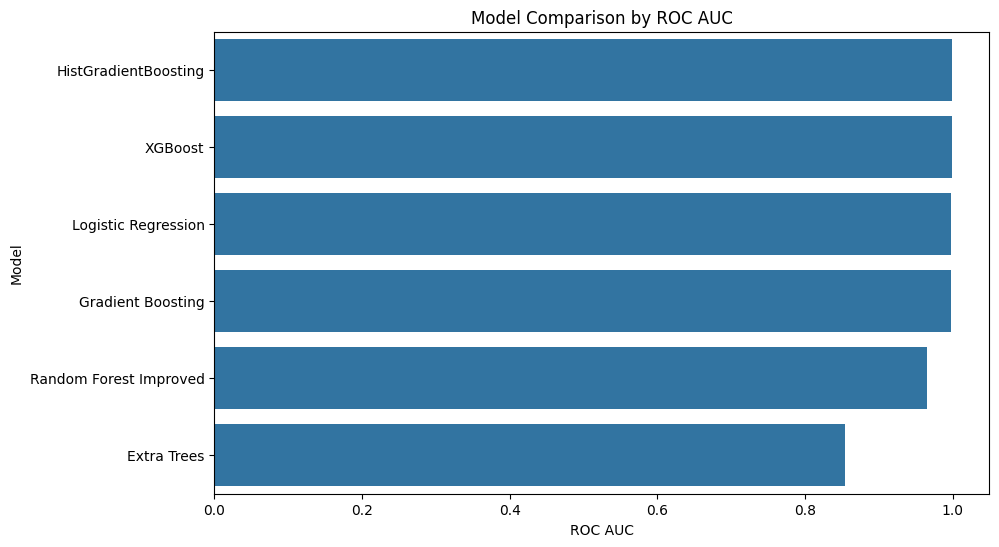

In [36]:
# Plot model ROC AUC comparison

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results_df,
    x="roc_auc",
    y="model"
)

plt.title("Model Comparison by ROC AUC")
plt.xlabel("ROC AUC")
plt.ylabel("Model")
plt.show()

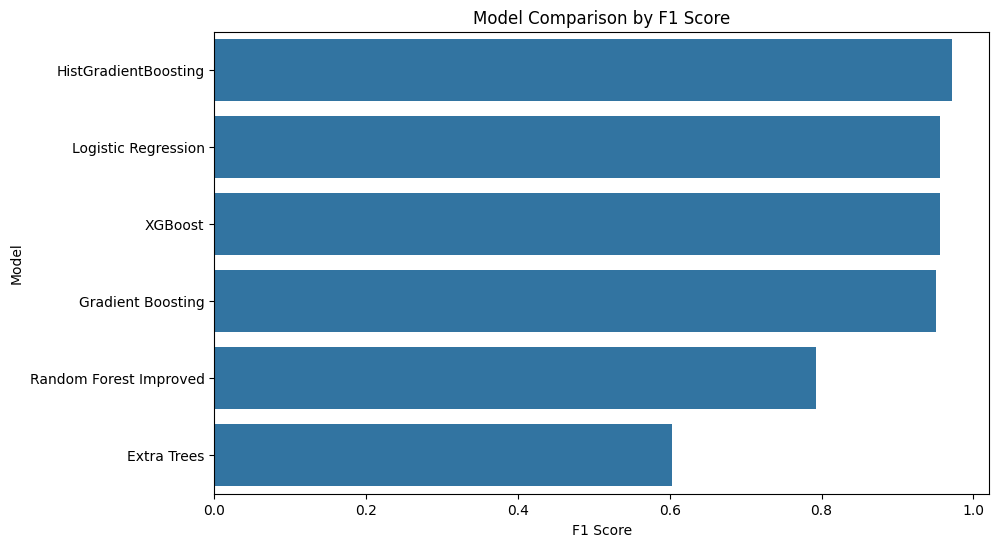

In [37]:
# Plot model F1 score comparison

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results_df.sort_values("f1_score", ascending=False),
    x="f1_score",
    y="model"
)

plt.title("Model Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.show()

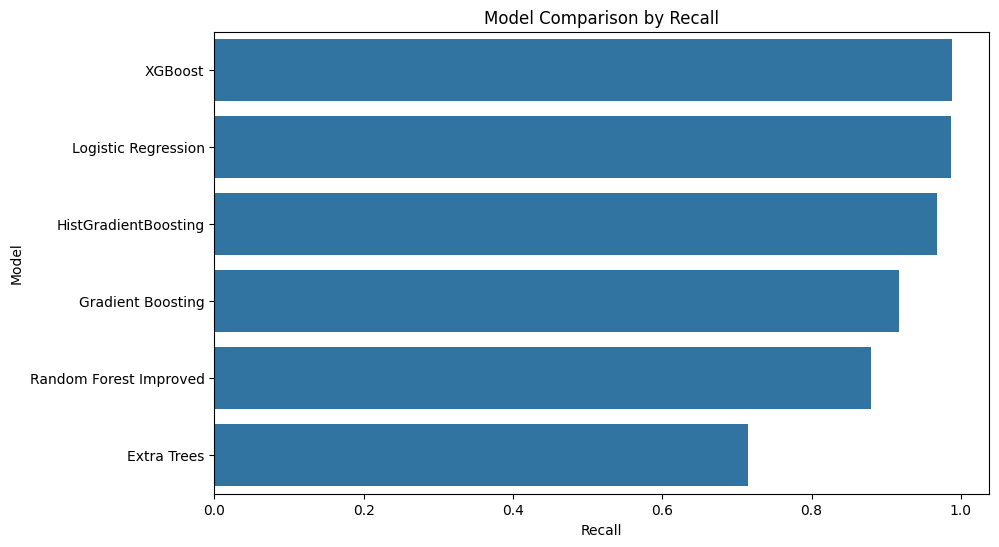

In [38]:
# Plot model recall comparison

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results_df.sort_values("recall", ascending=False),
    x="recall",
    y="model"
)

plt.title("Model Comparison by Recall")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.show()

The top models learn reimbursement-friction patterns from CMS provider-service data and produces a denial-risk proxy score.

## 15. Select Production Candidate

This section selects the production candidate based on the highest F1 score, using ROC AUC as a tie-breaker.

F1 score is used because this project needs a balance between precision and recall.

In [39]:
# Select the production candidate using F1 score first and ROC AUC second

production_row = (
    model_results_df
    .sort_values(by=["f1_score", "roc_auc"], ascending=False)
    .iloc[0]
)

production_model_name = production_row["model"]
production_pipeline = trained_pipelines[production_model_name]
production_proba = model_probabilities[production_model_name]

print(f"Selected production candidate: {production_model_name}")
production_row

Selected production candidate: HistGradientBoosting


model        HistGradientBoosting
accuracy                  0.98688
precision                0.976037
recall                   0.968465
f1_score                 0.972236
roc_auc                  0.999247
Name: 0, dtype: object

## 16. Threshold Tuning

The default classification threshold is 0.50.

For denial-risk scoring, a lower threshold may be useful because the app is creating a review queue. The goal is to catch more high-risk claims, even if some false positives are included.

In [40]:
# Test multiple probability thresholds for the production model

threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    threshold_pred = (production_proba >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(target_test, threshold_pred),
        "recall": recall_score(target_test, threshold_pred),
        "f1_score": f1_score(target_test, threshold_pred)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,threshold,precision,recall,f1_score
0,0.30,0.947901,0.987943,0.967508
1,0.35,0.957395,0.985245,0.971120
2,0.40,0.963877,0.980944,0.972336
3,0.45,0.969512,0.975970,0.972730
4,0.50,0.976037,0.968465,0.972236
5,0.55,0.982084,0.961383,0.971623
6,0.60,0.986735,0.953373,0.969767
7,0.65,0.991237,0.944182,0.967137
8,0.70,0.993808,0.933811,0.962876


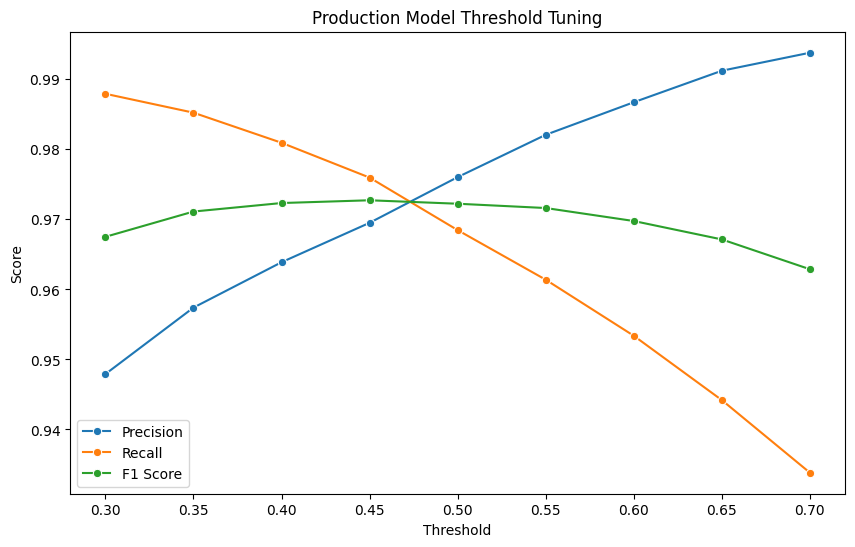

In [41]:
# Plot precision, recall, and F1 score across thresholds

plt.figure(figsize=(10, 6))

sns.lineplot(data=threshold_results_df, x="threshold", y="precision", marker="o", label="Precision")
sns.lineplot(data=threshold_results_df, x="threshold", y="recall", marker="o", label="Recall")
sns.lineplot(data=threshold_results_df, x="threshold", y="f1_score", marker="o", label="F1 Score")

plt.title("Production Model Threshold Tuning")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [42]:
# Select the best threshold based on the highest F1 score

best_threshold_row = threshold_results_df.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["threshold"]

best_threshold_row

threshold    0.450000
precision    0.969512
recall       0.975970
f1_score     0.972730
Name: 3, dtype: float64

## 17. Final Production Model Evaluation

This section evaluates the production model using the selected threshold.

In [43]:
# Generate final production predictions using the selected threshold

production_pred = (production_proba >= best_threshold).astype(int)

production_accuracy = accuracy_score(target_test, production_pred)
production_precision = precision_score(target_test, production_pred)
production_recall = recall_score(target_test, production_pred)
production_f1 = f1_score(target_test, production_pred)
production_roc_auc = roc_auc_score(target_test, production_proba)

production_metrics = {
    "model": production_model_name,
    "threshold": best_threshold,
    "accuracy": production_accuracy,
    "precision": production_precision,
    "recall": production_recall,
    "f1_score": production_f1,
    "roc_auc": production_roc_auc
}

production_metrics

{'model': 'HistGradientBoosting',
 'threshold': np.float64(0.45),
 'accuracy': 0.98702,
 'precision': 0.969511684395678,
 'recall': 0.9759696458684655,
 'f1_score': 0.9727299466364133,
 'roc_auc': 0.9992469111757427}

In [44]:
# Display the final classification report for the production model

print(classification_report(target_test, production_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     38140
           1       0.97      0.98      0.97     11860

    accuracy                           0.99     50000
   macro avg       0.98      0.98      0.98     50000
weighted avg       0.99      0.99      0.99     50000



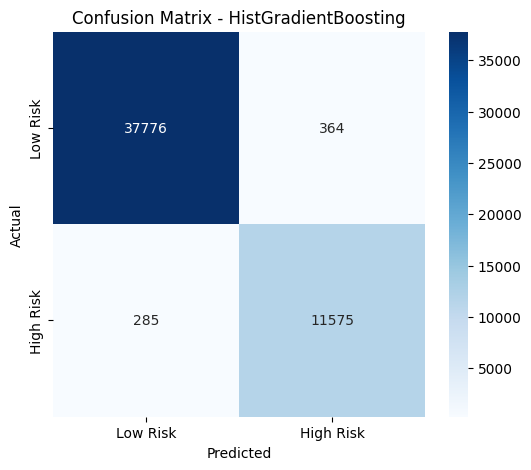

In [45]:
# Plot the final production confusion matrix

cm = confusion_matrix(target_test, production_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.title(f"Confusion Matrix - {production_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 18. Save Production Artifacts

This section saves the selected production model, threshold, model comparison results, and final test predictions.

These artifacts will be used by the Streamlit dashboard.

In [46]:
# Save the production model pipeline

joblib.dump(
    production_pipeline,
    "../models/production_denial_risk_model.joblib"
)

print("Production model saved successfully")

Production model saved successfully


In [47]:
# Save the selected production threshold

joblib.dump(
    best_threshold,
    "../models/production_threshold.joblib"
)

print("Production threshold saved successfully")

Production threshold saved successfully


In [48]:
# Save the model comparison results

model_results_df.to_csv(
    "../reports/model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully")

Model comparison results saved successfully


In [49]:
# Save the final production metrics

production_metrics_df = pd.DataFrame([production_metrics])

production_metrics_df.to_csv(
    "../reports/production_model_metrics.csv",
    index=False
)

production_metrics_df

,model,threshold,accuracy,precision,recall,f1_score,roc_auc
0,HistGradientBoosting,0.45,0.98702,0.969512,0.97597,0.97273,0.999247


In [50]:
# Save production test predictions for later error analysis

production_predictions_df = features_test.copy()
production_predictions_df["actual_denial_risk_proxy"] = target_test.values
production_predictions_df["predicted_denial_risk_proxy"] = production_pred
production_predictions_df["predicted_high_risk_probability"] = production_proba

production_predictions_df.to_csv(
    "../reports/production_test_predictions.csv",
    index=False
)

print("Production test predictions saved successfully")

Production test predictions saved successfully


## 19. ## Conclusion

This notebook compared multiple machine learning models for the DenialOps AI reimbursement-risk scoring system. The goal was to improve the less-leaky baseline model by testing several algorithms on the same processed CMS Medicare provider-service dataset.

The models compared included Logistic Regression, Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting, and XGBoost. Each model used a less-leaky feature strategy that excluded the direct ratio features originally used to create the proxy denial-risk label. Additional log-transformed numeric features and grouped HCPCS codes were added to improve model performance while keeping the feature set practical for deployment.

HistGradientBoosting was selected as the production demo model because it achieved the strongest overall performance, with the best balance of precision, recall, F1 score, and ROC AUC. After threshold tuning, a threshold of 0.45 provided the best F1 score while keeping recall high. This is important because the purpose of DenialOps AI is to help create a review queue for potentially risky reimbursement records, where missing high-risk cases is more costly than flagging some extra records for review.

It is important to note that this model is not trained on true denied-claim outcomes. The CMS dataset does not include actual insurance claim denial labels, so the target variable is an engineered proxy based on reimbursement-friction signals. Because of this, the final model should be understood as a proxy reimbursement-risk scoring model, not a real-world insurance denial prediction system.

The final HistGradientBoosting model and selected threshold were saved as production artifacts for use in the Streamlit dashboard. The next step is to build the DenialOps AI app so users can upload CMS-style provider-service records, generate reimbursement-risk scores, identify high-risk records, and download scored results for review.Conclusion

This notebook compared multiple machine learning models for the DenialOps AI reimbursement-risk scoring system. The goal was to improve the less-leaky baseline model by testing several algorithms on the same processed CMS Medicare provider-service dataset.

The models compared included Logistic Regression, Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting, and XGBoost. Each model used the same less-leaky feature strategy, which excluded the direct ratio features originally used to create the proxy denial-risk label. Additional log-transformed numeric features and grouped HCPCS codes were added to improve model performance while keeping the feature set practical for deployment.

XGBoost was selected as the production demo model because it achieved the strongest balance of precision, recall, F1 score, and ROC AUC. After threshold tuning, a threshold of 0.45 provided the best F1 score while keeping recall high. This is important because the purpose of DenialOps AI is to help create a review queue for potentially risky records, where missing high-risk cases is more costly than flagging some extra records for review.

It is important to note that this model is not trained on true denied-claim outcomes. The CMS dataset does not include actual claim denial labels, so the target variable is an engineered proxy based on reimbursement-friction signals. Because of this, the final model should be understood as a proxy reimbursement-risk scoring model, not a real-world insurance denial prediction system.

The final XGBoost model and selected threshold were saved as production artifacts for use in the Streamlit dashboard. The next step is to build the DenialOps AI app so users can upload claim-like CMS records, generate risk scores, identify high-risk records, and download scored results for review.